In [ ]:
import json
import numpy as np
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_4.npz"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]

NS_PATH = "data/Archive/NS/ns_run_5/ns/"

ns_elites_path = NS_PATH + "elites.json"

with open(ns_elites_path, "r") as f:
    elites_data = json.load(f)

# print the outline of the JSON structure
metadata = elites_data["metadata"]
elites = elites_data["elites"]
print("Number of elites:", len(elites))

Number of elites: 256


In [16]:
import sys
from mapelite.qd_runner import QDRunner
import mapelite.emitter as emitter_module
import mapelite.utils as utils_module
import mapelite.config as config_module
from scipy.spatial.distance import pdist, squareform
# Teach pickle that the old top-level 'emitter' is now 'mapelite.emitter'
sys.modules['emitter'] = emitter_module
sys.modules['utils'] = utils_module
sys.modules['config'] = config_module


# load from checkpoint
checkpoint_dir = NS_PATH + "checkpoints/"
state = QDRunner.get_state_from_checkpoint(checkpoint_dir)
stats = state["stats"]

print("stats keys:", stats[0].keys())
grid_state = stats[-1]["grid_plot"]
print("grid_state keys:", grid_state[-1].keys())

# sort grid_state by sub_count highest to lowest
grid_state_sorted = sorted(grid_state, key=lambda x: x["sub_count"], reverse=True)

print(grid_state_sorted[0]["elite"].keys())


2026-03-27 14:29:37 [info     ] Checkpoint loaded              path=data/Archive/NS/ns_run_5/ns/checkpoints\checkpoint_0999.pkl resume_iter=1000
stats keys: dict_keys(['iteration', 'initial_WSS', 'Archive size', 'iteration_best', 'global_best_score', 'global_best_id', 'new_elites', 'substituted_elites', 'wss', 'qd_score', 'acceptance_rate', 'mean_pairwise_dist', 'high_quality_coverage', 'mean_knn_novelty', 'fitness_novelty_corr', 'grid_plot'])
grid_state keys: dict_keys(['elite', 'sub_count', 'new', 'fitness'])
dict_keys(['id', 'mode', 'rngMode', 'dataSet', 'selectedCells'])


In [17]:
import umap
import os
import matplotlib.pyplot as plt
import numpy as np
# Cell to calculate and save UMAP model of precomputed embeddings
embeddings_data = _embeddings
print(f"Loaded precomputed embeddings with shape: {embeddings_data.shape}")

# Fit UMAP to the precomputed embeddings
umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model = umap_model.fit(embeddings_data)

#print umap max and min x,y values
umap_embeddings = umap_model.transform(embeddings_data)
print(f"UMAP embeddings x,y borders:")
print(f"x: min={umap_embeddings[:,0].min()}, max={umap_embeddings[:,0].max()}")
print(f"y: min={umap_embeddings[:,1].min()}, max={umap_embeddings[:,1].max()}")


Loaded precomputed embeddings with shape: (19154, 32)


d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embeddings x,y borders:
x: min=2.7036733627319336, max=11.095161437988281
y: min=2.992596387863159, max=11.910176277160645


Elite ID 739.1696245834466 UMAP 2D coords: [9.698037 9.1659  ]
Elite ID 969.4871469842748 UMAP 2D coords: [7.4331675 7.056424 ]


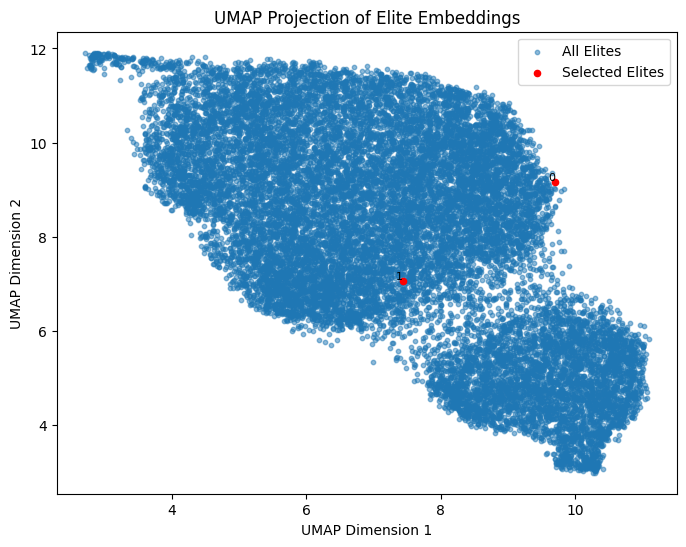

In [18]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
elite_ids = [739.1696245834466, 969.4871469842748]

# Preserve order of elite_ids
id_to_elite = {elite["id"]: elite for elite in elites}
selected_elites = [id_to_elite[eid] for eid in elite_ids if eid in id_to_elite]
selected_embeddings = [elite["embedding"] for elite in selected_elites]

reduced_points = []
for elite in selected_elites:
    embedding = elite["embedding"]
    point = umap_model.transform([embedding])[0]
    print(f"Elite ID {elite['id']} UMAP 2D coords: {point}")
    reduced_points.append(point)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1],
            s=10, alpha=0.5, label="All Elites")

reduced_points = np.array(reduced_points)
plt.scatter(reduced_points[:, 0], reduced_points[:, 1],
            s=20, color="red", label="Selected Elites")

# Add numbering based on order in elite_ids
for i, (x, y) in enumerate(reduced_points):
    plt.text(x, y, str(i), fontsize=8, ha='right', va='bottom', color='black')

plt.title("UMAP Projection of Elite Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.show()

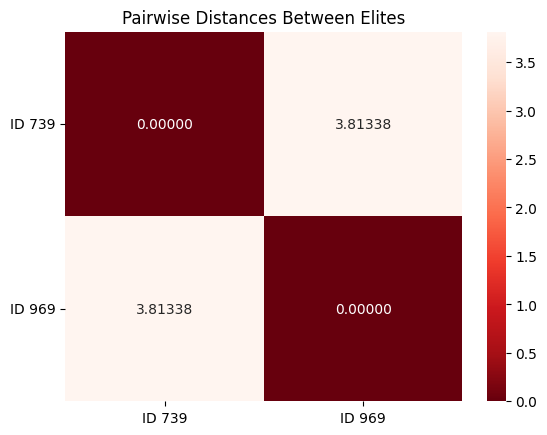

In [19]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

latent_distance_matrix = squareform(pdist(selected_embeddings, metric="euclidean"))

# shorten labels for readability
labels = [f"ID {id:.0f}" for id in elite_ids]

sns.heatmap(latent_distance_matrix, annot=True, cmap="Reds_r", xticklabels=labels, yticklabels=labels, fmt=".5f")
plt.title("Pairwise Distances Between Elites")
plt.yticks(rotation=0)
plt.show()

##### mean neighbor distance for top 5 and bottom 5 elites by sub_count

Top 5 elite IDs: [995.7091203327873, 995.671481978679, 999.8846591825778, 774.7403469172577, 979.2834096450655]
Top 5 sub_counts: [47, 33, 32, 28, 28]
Bottom 5 elite IDs: [995.4674543567868, 991.3007589504447, 971.8293743040651, 962.8147889252137, 956.4122988013925]
Bottom 5 sub_counts: [0, 0, 0, 0, 0]
Bottom 5 elite IDs (excluding zeros): [998.6417010476218, 943.8087173128382, 948.7930150267748, 838.9575778964274, 930.8369314989543]
Bottom 5 sub_counts (excluding zeros): [1, 1, 1, 1, 1]

--- Top 5 Candidates: Mean Neighborhood Distance (k=5) ---
Elite ID 995.671481978679: 1.9676
Elite ID 999.8846591825778: 1.8563
Elite ID 774.7403469172577: 2.2973
Elite ID 979.2834096450655: 2.3224

--- Bottom 5 Candidates: Mean Neighborhood Distance (k=5) ---
Elite ID 995.4674543567868: 2.2063
Elite ID 991.3007589504447: 2.2429
Elite ID 971.8293743040651: 1.2134
Elite ID 962.8147889252137: 1.7935
Elite ID 956.4122988013925: 2.3250

--- Bottom 5 Candidates (excluding zeros): Mean Neighborhood Distance

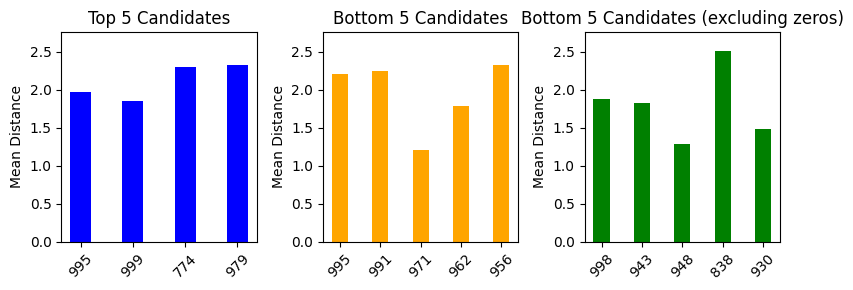

In [20]:
top_5_ids = [grid_state_sorted[i]["elite"]["id"] for i in range(5)]
top_5_counts = [grid_state_sorted[i]["sub_count"] for i in range(5)]
print("Top 5 elite IDs:", top_5_ids)
print("Top 5 sub_counts:", top_5_counts)
bottom_5_ids = [grid_state_sorted[-(i+1)]["elite"]["id"] for i in range(5)]
bottom_5_counts = [grid_state_sorted[-(i+1)]["sub_count"] for i in range(5)]
print("Bottom 5 elite IDs:", bottom_5_ids)
print("Bottom 5 sub_counts:", bottom_5_counts)

grid_state_excluded_zeros = [entry for entry in grid_state_sorted if entry["sub_count"] > 0]
bottom_5_ids_excluded_zeros = [grid_state_excluded_zeros[-(i+1)]["elite"]["id"] for i in range(5)]
bottom_5_counts_excluded_zeros = [grid_state_excluded_zeros[-(i+1)]["sub_count"] for i in range(5)]
print("Bottom 5 elite IDs (excluding zeros):", bottom_5_ids_excluded_zeros)
print("Bottom 5 sub_counts (excluding zeros):", bottom_5_counts_excluded_zeros)

top_5_elites =[elite for elite in elites if elite["id"] in top_5_ids]
top_5_elites = sorted(top_5_elites, key=lambda x: top_5_ids.index(x["id"]))

bottom_5_elites =[elite for elite in elites if elite["id"] in bottom_5_ids]
bottom_5_elites = sorted(bottom_5_elites, key=lambda x: bottom_5_ids.index(x["id"]))

bottom_5_elites_excluded_zeros =[elite for elite in elites if elite["id"] in bottom_5_ids_excluded_zeros]
bottom_5_elites_excluded_zeros = sorted(bottom_5_elites_excluded_zeros, key=lambda x: bottom_5_ids_excluded_zeros.index(x["id"]))

elite_embeddings = [elite["embedding"] for elite in elites]

# calculate mean neighborhood distance in the embedding space using nearest neighbor
from sklearn.neighbors import NearestNeighbors

k = 5
X = np.array(elite_embeddings)
knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
knn.fit(X)

def get_mean_k_distance(model,elite_group, k=k):
    results = []
    for elite in elite_group:
        query_vec = np.array(elite["embedding"]).reshape(1, -1)
        
        # Find distances to the nearest neighbors
        distances, indices = model.kneighbors(query_vec)
        distances = distances[0] # flatten the array
        
        # If the closest point is the point itself (distance ~ 0), exclude it
        if np.isclose(distances[0], 0.0, atol=1e-7):
            actual_neighbor_dists = distances[1:k+1] 
        else:
            # If the point wasn't in _embeddings, just take the first k neighbors
            actual_neighbor_dists = distances[:k]
            
        mean_distance = np.mean(actual_neighbor_dists)
        results.append((elite["id"], mean_distance))
        
    return results

# 2. Calculate for Top 5
print(f"\n--- Top 5 Candidates: Mean Neighborhood Distance (k={k}) ---")
top_5_distances = get_mean_k_distance(knn, top_5_elites)
for eid, dist in top_5_distances:
    print(f"Elite ID {eid}: {dist:.4f}")

# 3. Calculate for Bottom 5
print(f"\n--- Bottom 5 Candidates: Mean Neighborhood Distance (k={k}) ---")
bottom_5_distances = get_mean_k_distance(knn, bottom_5_elites)
for eid, dist in bottom_5_distances:
    print(f"Elite ID {eid}: {dist:.4f}")

# 4. Calculate for Bottom 5 (excluding zeros)
print(f"\n--- Bottom 5 Candidates (excluding zeros): Mean Neighborhood Distance (k={k}) ---")
bottom_5_distances_excluded_zeros = get_mean_k_distance(knn, bottom_5_elites_excluded_zeros)
for eid, dist in bottom_5_distances_excluded_zeros:
    print(f"Elite ID {eid}: {dist:.4f}")
    

# plot as side by side bar charts one for top 5 and one for bottom 5 one for bottom 5 excluding zeros
import matplotlib.pyplot as plt
def plot_mean_distances(top_distances, bottom_distances, bottom_excl_zeros_distances):
    top_ids, top_means = zip(*top_distances)
    bottom_ids, bottom_means = zip(*bottom_distances)
    bottom_excl_zeros_ids, bottom_excl_zeros_means = zip(*bottom_excl_zeros_distances)

    x_top = np.arange(len(top_ids))
    x_bottom = np.arange(len(bottom_ids))
    x_bottom_excl_zeros = np.arange(len(bottom_excl_zeros_ids))
    
    max_y = max(max(top_means), max(bottom_means), max(bottom_excl_zeros_means)) * 1.1

    plt.figure(figsize=(8, 3))

    plt.subplot(1, 3, 1)
    plt.bar(x_top, top_means, color='blue', width=0.4)
    plt.xticks(x_top, [str(int(eid)) for eid in top_ids], rotation=45)
    plt.title("Top 5 Candidates")
    plt.ylabel("Mean Distance")
    plt.ylim(0, max_y)

    plt.subplot(1, 3, 2)
    plt.bar(x_bottom, bottom_means, color='orange', width=0.4)
    plt.xticks(x_bottom, [str(int(eid)) for eid in bottom_ids], rotation=45)
    plt.title("Bottom 5 Candidates")
    plt.ylabel("Mean Distance")
    plt.ylim(0, max_y)

    plt.subplot(1, 3, 3)
    plt.bar(x_bottom_excl_zeros, bottom_excl_zeros_means, color='green', width=0.4)
    plt.xticks(x_bottom_excl_zeros, [str(int(eid)) for eid in bottom_excl_zeros_ids], rotation=45)
    plt.title("Bottom 5 Candidates (excluding zeros)")
    plt.ylabel("Mean Distance")
    plt.ylim(0, max_y)

    plt.tight_layout()
    plt.show()
    
plot_mean_distances(top_5_distances, bottom_5_distances, bottom_5_distances_excluded_zeros)


##### mean distance in embedding space of umap clusters


--- Near Elites: Mean Neighborhood Distance (k={k}) ---
Elite ID 233.41527199924525: 1.5766
Elite ID 374.84543222516254: 1.3218
Elite ID 508.7792614222694: 1.5066
Elite ID 402.1317828280899: 1.6569

--- Sparse Elites: Mean Neighborhood Distance (k={k}) ---
Elite ID 979.6166047852373: 1.9146
Elite ID 995.6815485034725: 1.9670
Elite ID 439.2284344674571: 1.7741


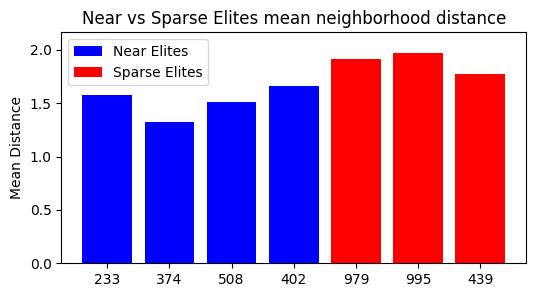

In [21]:
k = 15
X = np.array(_embeddings)
knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
knn.fit(X)


near_ids = [233.41527199924525, 374.84543222516254, 508.7792614222694, 402.1317828280899]
near_elites = [elite for elite in elites if elite["id"] in near_ids]

sparse_ids = [979.6166047852373,995.6815485034725, 439.2284344674571]
sparse_elites = [elite for elite in elites if elite["id"] in sparse_ids]

near_distances = get_mean_k_distance(knn, near_elites, k)
print("\n--- Near Elites: Mean Neighborhood Distance (k={k}) ---")
for eid, dist in near_distances:
    print(f"Elite ID {eid}: {dist:.4f}")

sparse_distances = get_mean_k_distance(knn, sparse_elites, k)
print("\n--- Sparse Elites: Mean Neighborhood Distance (k={k}) ---")
for eid, dist in sparse_distances:
    print(f"Elite ID {eid}: {dist:.4f}")

maxY = max(max([dist for _, dist in near_distances]), max([dist for _, dist in sparse_distances])) * 1.1

plt.figure(figsize=(6, 3))
plt.bar(x=[str(int(eid)) for eid, _ in near_distances], height=[dist for _, dist in near_distances], color='blue')

plt.bar(x=[str(int(eid)) for eid, _ in sparse_distances], height=[dist for _, dist in sparse_distances], color='red')
plt.title("Near vs Sparse Elites mean neighborhood distance")
plt.ylabel("Mean Distance")
plt.ylim(0, maxY)

# Add legend
plt.legend(["Near Elites", "Sparse Elites"])

plt.show()

